# HW 8: Bagging

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split

In [9]:
%load_ext pycodestyle_magic

In [2]:
def plot_cv_results(cv_results, param_x, param_z, metric='mean_test_score'):
    """
    cv_results - cv_results_ attribute of a GridSearchCV instance (or similar)
    param_x - name of grid search parameter to plot on x axis
    param_z - name of grid search parameter to plot by line color
    """
    cv_results = pd.DataFrame(cv_results)
    col_x = 'param_' + param_x
    col_z = 'param_' + param_z
    fig, ax = plt.subplots(1, 1, figsize=(11, 8))
    sns.pointplot(x=col_x, y=metric, hue=col_z, data=cv_results, ci=99, n_boot=64, ax=ax)
    plt.xticks(rotation=90)
    ax.set_title("CV Grid Search Results")
    ax.set_xlabel(param_x)
    ax.set_ylabel(metric)
    ax.legend(title=param_z)
    return fig

## Import data

In [3]:
df = pd.read_csv('data/train.csv')

In [4]:
descr = pd.read_excel('data/description.xlsx')

### Columns description

In [5]:
descr[['Variable Name', 'Description']]

,Variable Name,Description
0,UniqueID,Identifier for customers
1,loan_default,Payment default in the first EMI on due date
2,disbursed_amount,Amount of Loan disbursed
3,asset_cost,Cost of the Asset
4,ltv,Loan to Value of the asset
5,branch_id,Branch where the loan was disbursed
6,supplier_id,Vehicle Dealer where the loan was disbursed
7,manufacturer_id,"Vehicle manufacturer(Hero, Honda, TVS etc.)"
8,Current_pincode,Current pincode of the customer
9,Date.of.Birth,Date of birth of the customer


In [6]:
df.head()

,UniqueID,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,Date.of.Birth,Employment.Type,...,SEC.SANCTIONED.AMOUNT,SEC.DISBURSED.AMOUNT,PRIMARY.INSTAL.AMT,SEC.INSTAL.AMT,NEW.ACCTS.IN.LAST.SIX.MONTHS,DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS,AVERAGE.ACCT.AGE,CREDIT.HISTORY.LENGTH,NO.OF_INQUIRIES,loan_default
0,750296,42996,69150,63.60,18,22708,86,2728,31-12-88,Salaried,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
1,652580,37941,45536,84.68,5,13942,51,3425,01-01-78,Self employed,...,0,0,6298,0,1,0,0yrs 10mon,1yrs 5mon,0,0
2,697940,48651,65138,76.76,61,15897,45,1377,01-01-64,Salaried,...,0,0,100000,0,0,0,0yrs 8mon,1yrs 1mon,0,0
3,703152,60215,72684,83.88,136,17783,86,3708,10-08-98,NaN,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
4,603556,59615,72086,84.89,19,16938,86,1853,30-01-85,Self employed,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0


## Categorical features

In [7]:
df.dtypes[df.dtypes == 'object']

Date.of.Birth                    object
Employment.Type                  object
DisbursalDate                    object
PERFORM_CNS.SCORE.DESCRIPTION    object
AVERAGE.ACCT.AGE                 object
CREDIT.HISTORY.LENGTH            object
dtype: object

### Dealing with the customer age

In [10]:
df['Date.of.Birth'].head()

0    31-12-88
1    01-01-78
2    01-01-64
3    10-08-98
4    30-01-85
Name: Date.of.Birth, dtype: object

In [14]:
df['birth_year'] = (df['Date.of.Birth'].str.split('-').str[-1]).astype(int)
df['birth_year'] = (df['birth_year'] > 40) * (df['birth_year'] + 1900) +\
    (df['birth_year'] < 40) * (df['birth_year'] + 2000)
df['disb_year'] = (df['DisbursalDate'].str.split('-').str[-1]).astype(int)
df['disb_year'] = (df['disb_year'] > 40) * (df['disb_year'] + 1900) +\
    (df['disb_year'] < 40) * (df['disb_year'] + 2000)
df['customer_age'] = df['disb_year'] - df['birth_year']

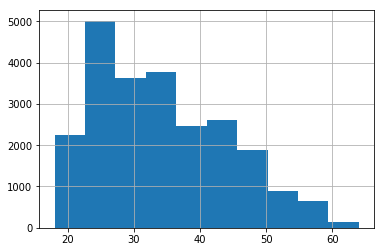

In [15]:
df['customer_age'].hist()

In [16]:
df = df.drop(['Date.of.Birth', 'DisbursalDate',
              'birth_year', 'disb_year'], axis=1)

### Employment

In [17]:
df['Employment.Type'].unique()

array(['Salaried', 'Self employed', nan], dtype=object)

In [18]:
df['Employment.Type'].value_counts(dropna=False)

Self employed    12761
Salaried          9757
NaN                797
Name: Employment.Type, dtype: int64

In [19]:
df = df.dropna(subset=['Employment.Type'])

In [20]:
df['Employment.Type'] = (df['Employment.Type'] == 'Salaried')

### PERFORM_CNS.SCORE.DESCRIPTION

In [21]:
df['PERFORM_CNS.SCORE.DESCRIPTION'].value_counts()

No Bureau History Available                                11158
C-Very Low Risk                                             1574
A-Very Low Risk                                             1376
D-Very Low Risk                                             1080
B-Very Low Risk                                              894
K-High Risk                                                  839
M-Very High Risk                                             836
F-Low Risk                                                   813
H-Medium Risk                                                670
E-Low Risk                                                   598
I-Medium Risk                                                559
J-High Risk                                                  381
G-Low Risk                                                   379
Not Scored: Not Enough Info available on the customer        363
Not Scored: Sufficient History Not Available                 358
Not Scored: No Activity s

In [26]:
df.loc[df['PERFORM_CNS.SCORE.DESCRIPTION']
       .str.contains('|'.join(['Not Scored', 'No Bureau'])),
       'PERFORM_CNS.SCORE.DESCRIPTION'] = ''

In [28]:
df['PERFORM_CNS.SCORE'].headad()

0      0
1    763
2    845
4      0
5      0
Name: PERFORM_CNS.SCORE, dtype: int64

In [29]:
df['PERFORM_CNS.SCORE.DESCRIPTION'].head()

0                   
1    B-Very Low Risk
2    A-Very Low Risk
4                   
5                   
Name: PERFORM_CNS.SCORE.DESCRIPTION, dtype: object

In [30]:
riskvals = ['Very Low Risk', 'Low Risk',
            'Medium Risk', 'High Risk',
            'Very High Risk']
for r in riskvals:
    df[r] = df['PERFORM_CNS.SCORE.DESCRIPTION'].str.contains(r)

In [31]:
df.head()

,UniqueID,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,Employment.Type,State_ID,...,AVERAGE.ACCT.AGE,CREDIT.HISTORY.LENGTH,NO.OF_INQUIRIES,loan_default,customer_age,Very Low Risk,Low Risk,Medium Risk,High Risk,Very High Risk
0,750296,42996,69150,63.60,18,22708,86,2728,True,4,...,0yrs 0mon,0yrs 0mon,0,0,30,False,False,False,False,False
1,652580,37941,45536,84.68,5,13942,51,3425,False,9,...,0yrs 10mon,1yrs 5mon,0,0,40,True,True,False,False,False
2,697940,48651,65138,76.76,61,15897,45,1377,True,6,...,0yrs 8mon,1yrs 1mon,0,0,54,True,True,False,False,False
4,603556,59615,72086,84.89,19,16938,86,1853,False,4,...,0yrs 0mon,0yrs 0mon,0,0,33,False,False,False,False,False
5,592147,41076,56318,78.06,3,18125,45,91,True,1,...,0yrs 0mon,0yrs 0mon,0,0,26,False,False,False,False,False


### AVERAGE.ACCT.AGE 

In [36]:
df['account_months'] = (df['AVERAGE.ACCT.AGE']
                        .str.split('yrs').str[0]).astype(int) * 12 + \
    df['AVERAGE.ACCT.AGE'].str.split('yrs').str[1].str.split('mon')\
    .str[0].astype(int)

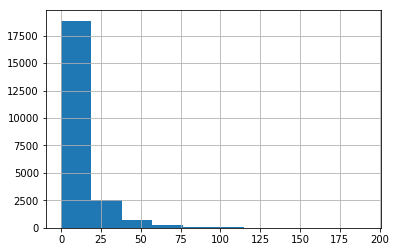

In [37]:
df['account_months'].hist()

### CREDIT.HISTORY.LENGTH

In [39]:
df['credit_months'] = (df['CREDIT.HISTORY.LENGTH'].str.split('yrs').str[0])\
    .astype(int)*12 + df['CREDIT.HISTORY.LENGTH'].str.split('yrs').str[1]\
    .str.split('mon').str[0].astype(int)

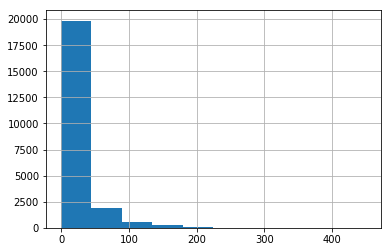

In [40]:
df['credit_months'].hist()

In [41]:
df = df.drop(df.dtypes[df.dtypes=='object'].index, axis=1)

### Check for NaN

In [42]:
df.isna().sum()[df.isna().sum() != 0]

Series([], dtype: int64)

In [43]:
df.head()

,UniqueID,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,Employment.Type,State_ID,...,NO.OF_INQUIRIES,loan_default,customer_age,Very Low Risk,Low Risk,Medium Risk,High Risk,Very High Risk,account_months,credit_months
0,750296,42996,69150,63.60,18,22708,86,2728,True,4,...,0,0,30,False,False,False,False,False,0,0
1,652580,37941,45536,84.68,5,13942,51,3425,False,9,...,0,0,40,True,True,False,False,False,10,17
2,697940,48651,65138,76.76,61,15897,45,1377,True,6,...,0,0,54,True,True,False,False,False,8,13
4,603556,59615,72086,84.89,19,16938,86,1853,False,4,...,0,0,33,False,False,False,False,False,0,0
5,592147,41076,56318,78.06,3,18125,45,91,True,1,...,0,0,26,False,False,False,False,False,0,0


## EDA

Checking the ID columns

In [46]:
df['branch_id'].nunique()

82

In [47]:
df['supplier_id'].nunique()

2337

In [48]:
df['manufacturer_id'].nunique()

10

In [49]:
df['Current_pincode_ID'].nunique()

4209

In [50]:
df['State_ID'].nunique()

22

In [51]:
df['Employee_code_ID'].nunique()

2950

Seems ok to drop ones with a lot of unique vals

In [52]:
df = df.drop(['supplier_id', 'Current_pincode_ID',
              'Employee_code_ID'], axis=1)

All the others go to one-hot encoding

In [53]:
df = pd.get_dummies(df, columns=['manufacturer_id',
                                 'branch_id', 'State_ID'])

In [54]:
df.head()

,UniqueID,disbursed_amount,asset_cost,ltv,Employment.Type,MobileNo_Avl_Flag,Aadhar_flag,PAN_flag,VoterID_flag,Driving_flag,...,State_ID_13,State_ID_14,State_ID_15,State_ID_16,State_ID_17,State_ID_18,State_ID_19,State_ID_20,State_ID_21,State_ID_22
0,750296,42996,69150,63.60,True,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,652580,37941,45536,84.68,False,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,697940,48651,65138,76.76,True,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,603556,59615,72086,84.89,False,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,592147,41076,56318,78.06,True,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0


### Checking some numerical features

In [55]:
num_cols = ['disbursed_amount', 'asset_cost', 'ltv']

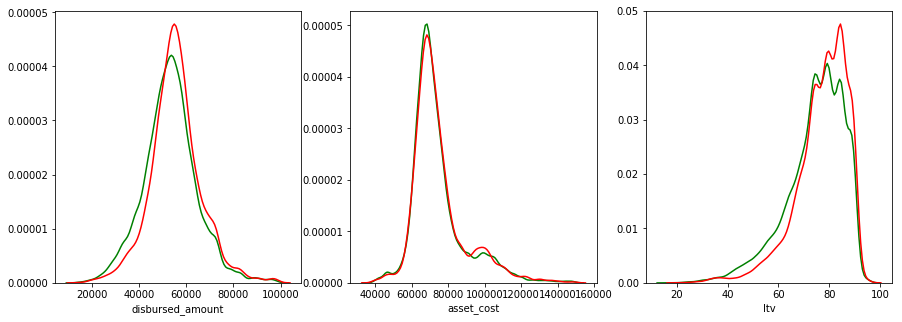

In [58]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
plot_data = df.copy()

plot_data = plot_data.loc[plot_data['disbursed_amount'] < 100000, :]
plot_data = plot_data.loc[plot_data['asset_cost'] < 150000, :]

feature_names = [c for c in num_cols if c != 'loan_default']
for name, ax in zip(feature_names, axs.flatten()):
    sns.distplot(plot_data.loc[plot_data['loan_default'] == 0, name],
                 ax=ax, color='green', kde=True, hist=False)
    sns.distplot(plot_data.loc[plot_data['loan_default'] == 1, name],
                 ax=ax, color='red', kde=True, hist=False)

In [59]:
more_vals = ['PERFORM_CNS.SCORE', 'PRI.NO.OF.ACCTS',
             'PRI.ACTIVE.ACCTS', 'PRI.OVERDUE.ACCTS',
             'PRI.CURRENT.BALANCE', 'PRI.SANCTIONED.AMOUNT',
             'PRI.DISBURSED.AMOUNT', 'SEC.NO.OF.ACCTS',
             'SEC.ACTIVE.ACCTS', 'SEC.OVERDUE.ACCTS',
             'SEC.CURRENT.BALANCE', 'SEC.SANCTIONED.AMOUNT',
             'SEC.DISBURSED.AMOUNT', 'PRIMARY.INSTAL.AMT',
             'SEC.INSTAL.AMT', 'NEW.ACCTS.IN.LAST.SIX.MONTHS',
             'DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS', 'NO.OF_INQUIRIES']

/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/ipykernel_launcher.py:15: RuntimeWarning: divide by zero encountered in log
  from ipykernel import kernelapp as app
/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in log
  from ipykernel import kernelapp as app
/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/ipykernel_launcher.py:19: RuntimeWarning: invalid value encountered in log
/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/statsmodels/nonparametric/kde.py:447: RuntimeWarning: invalid value encountered in greater
  X = X[np.logical_and(X > clip[0], X < clip[1])] # won't work for two columns.
/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/statsmodels/nonparametric/kde.py:447: RuntimeWarning: invalid value encountered in less
  X = X[np.logical_and(X > clip[0], X < clip[1])] # won't work for two columns.


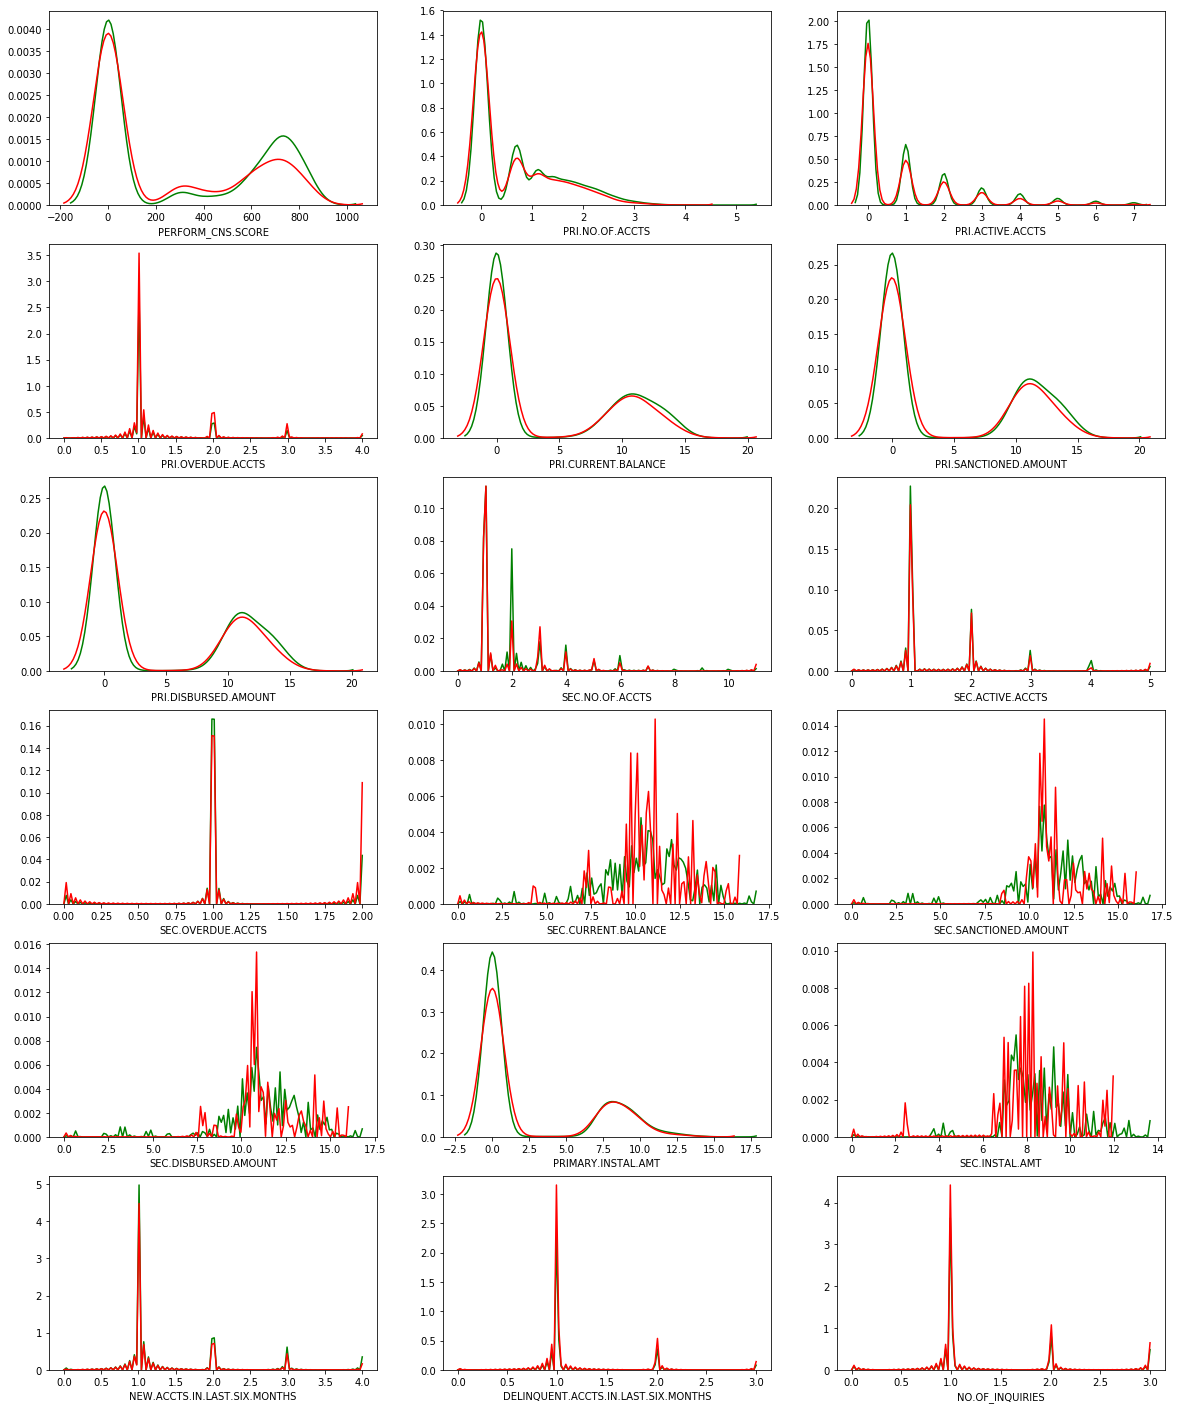

In [68]:
fig, axs = plt.subplots(6, 3, figsize=(20, 25))
plot_data = df.copy()

plot_data = plot_data.loc[plot_data['PRI.ACTIVE.ACCTS'] < 7.5, :]
plot_data = plot_data.loc[plot_data['PRI.OVERDUE.ACCTS'] < 5, :]
plot_data = plot_data.loc[plot_data['SEC.NO.OF.ACCTS'] < 12, :]
plot_data = plot_data.loc[plot_data['SEC.ACTIVE.ACCTS'] < 6, :]
plot_data = plot_data.loc[plot_data['SEC.OVERDUE.ACCTS'] < 3, :]
plot_data = plot_data.loc[plot_data['NEW.ACCTS.IN.LAST.SIX.MONTHS'] < 5, :]
plot_data = plot_data.loc[plot_data['DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS'] < 4,
                          :]
plot_data = plot_data.loc[plot_data['NO.OF_INQUIRIES'] < 4, :]

plot_data['PRI.NO.OF.ACCTS'] = np.log(plot_data['PRI.NO.OF.ACCTS']+1)
plot_data['PRI.CURRENT.BALANCE'] = np.log(plot_data['PRI.CURRENT.BALANCE']+1)
plot_data['PRI.SANCTIONED.AMOUNT'] = np.log(plot_data['PRI.SANCTIONED.AMOUNT']
                                            + 1)
plot_data['PRI.DISBURSED.AMOUNT'] = np.log(plot_data['PRI.DISBURSED.AMOUNT']+1)
plot_data['SEC.CURRENT.BALANCE'] = np.log(plot_data['SEC.CURRENT.BALANCE']+1)
plot_data['SEC.SANCTIONED.AMOUNT'] = np.log(plot_data['SEC.SANCTIONED.AMOUNT']
                                            + 1)
plot_data['SEC.DISBURSED.AMOUNT'] = np.log(plot_data['SEC.DISBURSED.AMOUNT']+1)
plot_data['PRIMARY.INSTAL.AMT'] = np.log(plot_data['PRIMARY.INSTAL.AMT']+1)
plot_data['SEC.INSTAL.AMT'] = np.log(plot_data['SEC.INSTAL.AMT']+1)

feature_names = [c for c in more_vals if c != 'loan_default']
for name, ax in zip(feature_names, axs.flatten()):
    sns.distplot(plot_data.loc[plot_data['loan_default'] == 0, name],
                 ax=ax, color='green', kde=True, hist=False)
    sns.distplot(plot_data.loc[plot_data['loan_default'] == 1, name],
                 ax=ax, color='red', kde=True, hist=False)

### Checking out the noisy data

In [69]:
(df['SEC.CURRENT.BALANCE'] != 0).sum()/\
    (df['SEC.CURRENT.BALANCE'] == 0).sum()

0.014964391958892995

In [70]:
(df['SEC.SANCTIONED.AMOUNT'] != 0).sum()/\
    (df['SEC.SANCTIONED.AMOUNT'] == 0).sum()

0.016338689294096407

In [71]:
(df['SEC.DISBURSED.AMOUNT'] != 0).sum()/\
    (df['SEC.DISBURSED.AMOUNT'] == 0).sum()

0.016338689294096407

In [72]:
(df['SEC.INSTAL.AMT'] != 0).sum()/\
    (df['SEC.INSTAL.AMT'] == 0).sum()

0.009866355726971029

Considering that most of them are zero, dropping these columns:

In [89]:
def filter_data(df, istrain):
    plot_data = df.copy()

    plot_data = plot_data.drop(['SEC.CURRENT.BALANCE',
                                'SEC.SANCTIONED.AMOUNT',
                                'SEC.DISBURSED.AMOUNT',
                                'SEC.INSTAL.AMT'], axis=1)

    if istrain:
        plot_data = plot_data.loc[plot_data['disbursed_amount'] < 100000, :]
        plot_data = plot_data.loc[plot_data['asset_cost'] < 150000, :]

        plot_data = plot_data.loc[plot_data['PRI.ACTIVE.ACCTS'] < 7.5, :]
        plot_data = plot_data.loc[plot_data['PRI.OVERDUE.ACCTS'] < 5, :]
        plot_data = plot_data.loc[plot_data['SEC.NO.OF.ACCTS'] < 12, :]
        plot_data = plot_data.loc[plot_data['SEC.ACTIVE.ACCTS'] < 6, :]
        plot_data = plot_data.loc[plot_data['SEC.OVERDUE.ACCTS'] < 3, :]
        plot_data = plot_data.loc[plot_data['NEW.ACCTS.IN.LAST.SIX.MONTHS']
                                  < 5, :]
        plot_data = \
            plot_data.loc[plot_data['DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS']
                          < 4, :]
        plot_data = plot_data.loc[plot_data['NO.OF_INQUIRIES'] < 4, :]

    plot_data['PRI.NO.OF.ACCTS'] = np.log(plot_data['PRI.NO.OF.ACCTS'] + 1)
    plot_data.loc[df['PRI.CURRENT.BALANCE'] < 0, 'PRI.CURRENT.BALANCE'] = 0

    plot_data['PRI.CURRENT.BALANCE'] = np.log(plot_data['PRI.CURRENT.BALANCE']
                                              + 1)

    plot_data['PRI.SANCTIONED.AMOUNT'] = \
        np.log(plot_data['PRI.SANCTIONED.AMOUNT'] + 1)
    plot_data['PRI.DISBURSED.AMOUNT'] = \
        np.log(plot_data['PRI.DISBURSED.AMOUNT'] + 1)
    plot_data['PRIMARY.INSTAL.AMT'] = \
        np.log(plot_data['PRIMARY.INSTAL.AMT'] + 1)

    return plot_data

In [90]:
filtered_df = filter_data(df, istrain=True)

In [91]:
filtered_df.shape

(21606, 148)

## Model

### Random Forest with default parameters

In [92]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,\
    cross_val_score, GridSearchCV, RandomizedSearchCV

feature_cols = filtered_df.columns[(filtered_df.columns !=
                                    'loan_default') & 
                                   (filtered_df.columns != 'UniqueID')]

X_train, X_test, y_train, y_test = train_test_split(
    filtered_df.loc[:, feature_cols], 
    filtered_df['loan_default'], 
    test_size=0.3, random_state=42)

In [93]:
rf = RandomForestClassifier(n_jobs=-1).fit(X_train, y_train)

print("Random forest accuracy: %.3f" % rf.score(X_test, y_test))

/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/sklearn/ensemble/forest.py:245: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


Random forest accuracy: 0.759


In [94]:
sorted(list(zip(rf.feature_importances_, feature_cols)), key=lambda x:x[0], reverse=True)

[(0.1204256836083541, 'ltv'),
 (0.11226972928578369, 'disbursed_amount'),
 (0.11060851099193338, 'asset_cost'),
 (0.09162215887758876, 'customer_age'),
 (0.026718035278316836, 'PERFORM_CNS.SCORE'),
 (0.02605840483525243, 'credit_months'),
 (0.024816841308775844, 'account_months'),
 (0.02451097675648866, 'PRIMARY.INSTAL.AMT'),
 (0.024154587752505882, 'PRI.SANCTIONED.AMOUNT'),
 (0.02348460914572313, 'PRI.CURRENT.BALANCE'),
 (0.023137057966667006, 'PRI.DISBURSED.AMOUNT'),
 (0.01874751362365701, 'Employment.Type'),
 (0.016902007296525794, 'PRI.NO.OF.ACCTS'),
 (0.014199542982736242, 'manufacturer_id_86'),
 (0.014104138521033718, 'NO.OF_INQUIRIES'),
 (0.013359753382926137, 'manufacturer_id_45'),
 (0.011578368172611908, 'PRI.ACTIVE.ACCTS'),
 (0.008447617427079538, 'manufacturer_id_51'),
 (0.00825516427678625, 'NEW.ACCTS.IN.LAST.SIX.MONTHS'),
 (0.007764523190337117, 'Aadhar_flag'),
 (0.007637868163746394, 'PAN_flag'),
 (0.007215654231022923, 'VoterID_flag'),
 (0.006976291020415739, 'State_ID_4

In [95]:
score = cross_val_score(rf, X_train, y_train, scoring='roc_auc', cv=5)
print(score)
print(f'mean: {score.mean()}')
print(f'std: {score.std()}')

[0.5785062  0.56878601 0.58836486 0.57489495 0.58554327]
mean: 0.5792190581372838
std: 0.007095013720734311


### GridSearchCV

In [96]:
params = {'n_estimators': [1000],
          'max_features': ['sqrt'],
          'max_depth': [30],
          'min_samples_split': np.arange(30, 70, 5),
          'min_samples_leaf' : np.arange(1, 10, 1),
          'bootstrap' :[True]
}

best_forest = RandomizedSearchCV(
    RandomForestClassifier(random_state=42), 
    params,
    verbose=100,
    n_jobs=-1,
    cv=5,
    scoring='roc_auc'
)

best_forest.fit(
    X_train,y_train
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
Pickling array (shape=(146,), dtype=object).
Pickling array (shape=(15124,), dtype=int64).
Memmapping (shape=(20, 15124), dtype=int64) to new file /dev/shm/joblib_memmapping_folder_22533_6846381009/22533-139673613530112-737d80c4d0fb4d448184201427ff1c47.pkl
Pickling array (shape=(6, 15124), dtype=float64).
Pickling array (shape=(6, 15124), dtype=bool).
Memmapping (shape=(114, 15124), dtype=uint8) to new file /dev/shm/joblib_memmapping_folder_22533_6846381009/22533-139673613530112-69d87849fef44b6aa1874377b47c4d5b.pkl
Pickling array (shape=(20,), dtype=object).
Pickling array (shape=(6,), dtype=object).
Pickling array (shape=(6,), dtype=object).
Pickling array (shape=(114,), dtype=object).
Pickling array (shape=(20,), dtype=int64).
Pickling array (shape=(6,), dtype=int64).
Pickling array (shape=(6,), dtype=int64).
Pickling array (shape=(15124,), dtype=in

[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   44.9s
Pickling array (shape=(146,), dtype=object).
Pickling array (shape=(15124,), dtype=int64).
Memmapping (shape=(20, 15124), dtype=int64) to old file /dev/shm/joblib_memmapping_folder_22533_6846381009/22533-139673613530112-737d80c4d0fb4d448184201427ff1c47.pkl
Pickling array (shape=(6, 15124), dtype=float64).
Pickling array (shape=(6, 15124), dtype=bool).
Memmapping (shape=(114, 15124), dtype=uint8) to old file /dev/shm/joblib_memmapping_folder_22533_6846381009/22533-139673613530112-69d87849fef44b6aa1874377b47c4d5b.pkl
Pickling array (shape=(20,), dtype=object).
Pickling array (shape=(6,), dtype=object).
Pickling array (shape=(6,), dtype=object).
Pickling array (shape=(114,), dtype=object).
Pickling array (shape=(20,), dtype=int64).
Pickling array (shape=(6,), dtype=int64).
Pickling array (shape=(6,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(

[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  1.5min
Pickling array (shape=(146,), dtype=object).
Pickling array (shape=(15124,), dtype=int64).
Memmapping (shape=(20, 15124), dtype=int64) to old file /dev/shm/joblib_memmapping_folder_22533_6846381009/22533-139673613530112-737d80c4d0fb4d448184201427ff1c47.pkl
Pickling array (shape=(6, 15124), dtype=float64).
Pickling array (shape=(6, 15124), dtype=bool).
Memmapping (shape=(114, 15124), dtype=uint8) to old file /dev/shm/joblib_memmapping_folder_22533_6846381009/22533-139673613530112-69d87849fef44b6aa1874377b47c4d5b.pkl
Pickling array (shape=(20,), dtype=object).
Pickling array (shape=(6,), dtype=object).
Pickling array (shape=(6,), dtype=object).
Pickling array (shape=(114,), dtype=object).
Pickling array (shape=(20,), dtype=int64).
Pickling array (shape=(6,), dtype=int64).
Pickling array (shape=(6,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(

[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:  2.1min
Pickling array (shape=(146,), dtype=object).
Pickling array (shape=(15124,), dtype=int64).
Memmapping (shape=(20, 15124), dtype=int64) to old file /dev/shm/joblib_memmapping_folder_22533_6846381009/22533-139673613530112-737d80c4d0fb4d448184201427ff1c47.pkl
Pickling array (shape=(6, 15124), dtype=float64).
Pickling array (shape=(6, 15124), dtype=bool).
Memmapping (shape=(114, 15124), dtype=uint8) to old file /dev/shm/joblib_memmapping_folder_22533_6846381009/22533-139673613530112-69d87849fef44b6aa1874377b47c4d5b.pkl
Pickling array (shape=(20,), dtype=object).
Pickling array (shape=(6,), dtype=object).
Pickling array (shape=(6,), dtype=object).
Pickling array (shape=(114,), dtype=object).
Pickling array (shape=(20,), dtype=int64).
Pickling array (shape=(6,), dtype=int64).
Pickling array (shape=(6,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(

[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  2.7min
Pickling array (shape=(146,), dtype=object).
Pickling array (shape=(15124,), dtype=int64).
Memmapping (shape=(20, 15124), dtype=int64) to old file /dev/shm/joblib_memmapping_folder_22533_6846381009/22533-139673613530112-737d80c4d0fb4d448184201427ff1c47.pkl
Pickling array (shape=(6, 15124), dtype=float64).
Pickling array (shape=(6, 15124), dtype=bool).
Memmapping (shape=(114, 15124), dtype=uint8) to old file /dev/shm/joblib_memmapping_folder_22533_6846381009/22533-139673613530112-69d87849fef44b6aa1874377b47c4d5b.pkl
Pickling array (shape=(20,), dtype=object).
Pickling array (shape=(6,), dtype=object).
Pickling array (shape=(6,), dtype=object).
Pickling array (shape=(114,), dtype=object).
Pickling array (shape=(20,), dtype=int64).
Pickling array (shape=(6,), dtype=int64).
Pickling array (shape=(6,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(

[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:  3.3min
Pickling array (shape=(146,), dtype=object).
Pickling array (shape=(15124,), dtype=int64).
Memmapping (shape=(20, 15124), dtype=int64) to old file /dev/shm/joblib_memmapping_folder_22533_6846381009/22533-139673613530112-737d80c4d0fb4d448184201427ff1c47.pkl
Pickling array (shape=(6, 15124), dtype=float64).
Pickling array (shape=(6, 15124), dtype=bool).
Memmapping (shape=(114, 15124), dtype=uint8) to old file /dev/shm/joblib_memmapping_folder_22533_6846381009/22533-139673613530112-69d87849fef44b6aa1874377b47c4d5b.pkl
Pickling array (shape=(20,), dtype=object).
Pickling array (shape=(6,), dtype=object).
Pickling array (shape=(6,), dtype=object).
Pickling array (shape=(114,), dtype=object).
Pickling array (shape=(20,), dtype=int64).
Pickling array (shape=(6,), dtype=int64).
Pickling array (shape=(6,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(

[Parallel(n_jobs=-1)]: Done  41 out of  50 | elapsed:  3.9min remaining:   51.5s
Pickling array (shape=(146,), dtype=object).
Pickling array (shape=(15124,), dtype=int64).
Memmapping (shape=(20, 15124), dtype=int64) to old file /dev/shm/joblib_memmapping_folder_22533_6846381009/22533-139673613530112-737d80c4d0fb4d448184201427ff1c47.pkl
Pickling array (shape=(6, 15124), dtype=float64).
Pickling array (shape=(6, 15124), dtype=bool).
Memmapping (shape=(114, 15124), dtype=uint8) to old file /dev/shm/joblib_memmapping_folder_22533_6846381009/22533-139673613530112-69d87849fef44b6aa1874377b47c4d5b.pkl
Pickling array (shape=(20,), dtype=object).
Pickling array (shape=(6,), dtype=object).
Pickling array (shape=(6,), dtype=object).
Pickling array (shape=(114,), dtype=object).
Pickling array (shape=(20,), dtype=int64).
Pickling array (shape=(6,), dtype=int64).
Pickling array (shape=(6,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pick

RandomizedSearchCV(cv=5, error_score='raise-deprecating',
                   estimator=RandomForestClassifier(bootstrap=True,
                                                    class_weight=None,
                                                    criterion='gini',
                                                    max_depth=None,
                                                    max_features='auto',
                                                    max_leaf_nodes=None,
                                                    min_impurity_decrease=0.0,
                                                    min_impurity_split=None,
                                                    min_samples_leaf=1,
                                                    min_samples_split=2,
                                                    min_weight_fraction_leaf=0.0,
                                                    n_estimators='warn',
                                                    n_jobs=None

In [97]:
best_forest.best_params_

{'n_estimators': 1000,
 'min_samples_split': 35,
 'min_samples_leaf': 7,
 'max_features': 'sqrt',
 'max_depth': 30,
 'bootstrap': True}

In [98]:
best_forest.best_score_

0.6504314806521264

In [99]:
score = cross_val_score(best_forest.best_estimator_,
                        X_train, y_train,
                        scoring='roc_auc', cv=5)
print(score)
print(f'mean: {score.mean()}')
print(f'std: {score.std()}')

[0.66547327 0.65086225 0.64429889 0.64502139 0.64650031]
mean: 0.6504312207397694
std: 0.00785840844245707


## Results submission

In [107]:
def preprocess(df):
    df['birth_year'] = (df['Date.of.Birth'].str.split('-').str[-1]).astype(int)
    df['birth_year'] = (df['birth_year'] > 40) * (df['birth_year'] + 1900) + \
        (df['birth_year'] < 40) * (df['birth_year'] + 2000)
    df['disb_year'] = (df['DisbursalDate'].str.split('-').str[-1]).astype(int)
    df['disb_year'] = (df['disb_year'] > 40) * (df['disb_year'] + 1900) + \
        (df['disb_year'] < 40) * (df['disb_year'] + 2000)
    df['customer_age'] = df['disb_year'] - df['birth_year']

    df = df.drop(['Date.of.Birth', 'DisbursalDate', 'birth_year',
                  'disb_year'], axis=1)

    df['Employment.Type'] = (df['Employment.Type'] == 'Salaried')

    df.loc[df['PERFORM_CNS.SCORE.DESCRIPTION']
           .str.contains('|'.join(['Not Scored', 'No Bureau'])),
           'PERFORM_CNS.SCORE.DESCRIPTION'] = ''
    riskvals = ['Very Low Risk', 'Low Risk', 'Medium Risk',
                'High Risk', 'Very High Risk']
    for r in riskvals:
        df[r] = df['PERFORM_CNS.SCORE.DESCRIPTION'].str.contains(r)

    df['account_months'] = (df['AVERAGE.ACCT.AGE'].str.split('yrs')
                            .str[0]).astype(int) * 12 + \
        df['AVERAGE.ACCT.AGE'].str.split('yrs').str[1]\
        .str.split('mon').str[0].astype(int)
    df['credit_months'] = (df['CREDIT.HISTORY.LENGTH'].str.split('yrs')
                           .str[0]).astype(int) * 12 + \
        df['CREDIT.HISTORY.LENGTH'].str.split('yrs').str[1]\
        .str.split('mon').str[0].astype(int)

    df = df.drop(df.dtypes[df.dtypes == 'object'].index, axis=1)

    df = df.drop(['supplier_id', 'Current_pincode_ID', 'Employee_code_ID'],
                 axis=1)

    df = pd.get_dummies(df, columns=['manufacturer_id', 'branch_id',
                                     'State_ID'])

    filtered_df = filter_data(df, istrain=False)

    return filtered_df

In [108]:
test_df = pd.read_csv('data/test.csv')

In [109]:
test_df.shape

(23316, 40)

In [110]:
proc_test = preprocess(test_df)

In [111]:
diff = set(filtered_df.columns[filtered_df.columns != 'loan_default'])\
    - set(proc_test.columns)

In [112]:
for c in diff:
    proc_test[c] = [0] * proc_test.shape[0]

In [113]:
proc_test.shape

(23316, 147)

In [114]:
filtered_df.shape

(21606, 148)

In [116]:
y_pred = best_forest.best_estimator_\
    .predict_proba(proc_test.loc[:, proc_test.columns != 'UniqueID'])[:, 1]

sub_df = pd.concat([proc_test['UniqueID'], pd.Series(y_pred)],
                   axis=1, ignore_index=True)

sub_df.columns = ['UniqueID', 'loan_default']

In [117]:
sub_df.head()

,UniqueID,loan_default
0,535191,0.169209
1,565698,0.198355
2,536003,0.169646
3,628720,0.185439
4,627276,0.138503


In [118]:
sub_df = sub_df.set_index('UniqueID')

In [119]:
sub_df.to_csv('data/predicted.csv')

### LinearSVC Bagging

Standardizing

In [120]:
from sklearn.preprocessing import StandardScaler

In [125]:
norm_data = filtered_df.copy()
norm_data.loc[:, norm_data.columns != 'loan_default'] = \
    pd.DataFrame(data=StandardScaler()
                 .fit_transform(norm_data
                                .loc[:, norm_data.columns
                                     != 'loan_default']),
                 index=norm_data.index, columns=[c for c in
                                                 norm_data.columns
                                                 if c != 'loan_default'])

In [126]:
from sklearn.svm import LinearSVC
from sklearn.ensemble import BaggingClassifier

X_train, X_test, y_train, y_test = \
    train_test_split(norm_data.loc[:, feature_cols],
                     norm_data['loan_default'],
                     test_size=0.3)

lin_svm = LinearSVC().fit(X_train, y_train)

bag_svm = BaggingClassifier(LinearSVC(max_iter=5000),
                            n_jobs=-1).fit(X_train, y_train)

print("One SVM accuracy: %.2f" % lin_svm.score(X_test, y_test))
print("Random patching of SVMs accuracy: %.2f" % bag_svm.score(X_test, y_test))

/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/sklearn/svm/base.py:929: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)


One SVM accuracy: 0.78
Random patching of SVMs accuracy: 0.78


Single LinearSVM doesn't seem to converge.

### Trying RBF kernel

In [127]:
from sklearn.kernel_approximation import Nystroem

In [128]:
feature_map_nystroem = Nystroem()

data_transformed = feature_map_nystroem.fit_transform(X_train)
test_transformed=feature_map_nystroem.transform(X_test)

In [129]:
lin_svm = LinearSVC(C=10).fit(data_transformed, y_train)

bag_svm = BaggingClassifier(LinearSVC(),
                            n_jobs=-1).fit(data_transformed,
                                           y_train)

print("One SVM accuracy: %.2f" %
      lin_svm.score(test_transformed, y_test))
print("Random patching of SVMs accuracy: %.2f" % 
      bag_svm.score(test_transformed, y_test))

One SVM accuracy: 0.78
Random patching of SVMs accuracy: 0.78


In [130]:
params = {'n_estimators': np.arange(10, 100, 20),
          'max_features': np.arange(0.5, 1, 0.1),
          'max_samples': np.arange(0.5, 1, 0.1),
          'bootstrap': [True, False],
          'bootstrap_features': [True, False]
         }

best_bag = RandomizedSearchCV(
    BaggingClassifier(LinearSVC(), n_jobs=-1), 
    params,
    verbose=100,
    n_jobs=-1,
    cv=5,
    scoring='roc_auc'
)

best_bag.fit(
    data_transformed,y_train
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
Memmapping (shape=(15124, 100), dtype=float64) to new file /dev/shm/joblib_memmapping_folder_22533_3134307568/22533-139673381742408-86c70491425347dc9743c7b2ef127f48.pkl
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(12098,), dtype=int64).
Pickling array (shape=(3026,), dtype=int64).
Memmapping (shape=(15124, 100), dtype=float64) to old file /dev/shm/joblib_memmapping_folder_22533_3134307568/22533-139673381742408-86c70491425347dc9743c7b2ef127f48.pkl
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(12099,), dtype=int64).
Pickling array (shape=(3025,), dtype=int64).
Memmapping (shape=(15124, 100), dtype=float64) to old file /dev/shm

[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:   57.4s
Memmapping (shape=(15124, 100), dtype=float64) to old file /dev/shm/joblib_memmapping_folder_22533_3134307568/22533-139673381742408-86c70491425347dc9743c7b2ef127f48.pkl
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(12100,), dtype=int64).
Pickling array (shape=(3024,), dtype=int64).
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:   57.6s
Memmapping (shape=(15124, 100), dtype=float64) to old file /dev/shm/joblib_memmapping_folder_22533_3134307568/22533-139673381742408-86c70491425347dc9743c7b2ef127f48.pkl
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(12098,), dtype=int64).
Pickling array (shape=(3026,), dtype=int64).
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:   58.6s
Memmapping (shape=

/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/joblib/externals/loky/process_executor.py:706: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  "timeout or by a memory leak.", UserWarning


Memmapping (shape=(15124, 100), dtype=float64) to old file /dev/shm/joblib_memmapping_folder_22533_3134307568/22533-139673381742408-86c70491425347dc9743c7b2ef127f48.pkl
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(12100,), dtype=int64).
Pickling array (shape=(3024,), dtype=int64).
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:  2.2min
Memmapping (shape=(15124, 100), dtype=float64) to old file /dev/shm/joblib_memmapping_folder_22533_3134307568/22533-139673381742408-86c70491425347dc9743c7b2ef127f48.pkl
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(15124,), dtype=int64).
Pickling array (shape=(12100,), dtype=int64).
Pickling array (shape=(3024,), dtype=int64).
[Parallel(n_jobs=-1)]: Done  27 tasks      | elapsed:  2.3min
Memmapping (shape=(15124, 100), dtype=float64) to old file /dev/shm/joblib_memma

[Parallel(n_jobs=-1)]: Done  46 out of  50 | elapsed:  2.9min remaining:   15.2s
[Parallel(n_jobs=-1)]: Done  47 out of  50 | elapsed:  2.9min remaining:   11.1s
[Parallel(n_jobs=-1)]: Done  48 out of  50 | elapsed:  2.9min remaining:    7.3s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  2.9min remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  2.9min finished


RandomizedSearchCV(cv=5, error_score='raise-deprecating',
                   estimator=BaggingClassifier(base_estimator=LinearSVC(C=1.0,
                                                                        class_weight=None,
                                                                        dual=True,
                                                                        fit_intercept=True,
                                                                        intercept_scaling=1,
                                                                        loss='squared_hinge',
                                                                        max_iter=1000,
                                                                        multi_class='ovr',
                                                                        penalty='l2',
                                                                        random_state=None,
                                                       

In [131]:
best_bag.best_estimator_.score(test_transformed, y_test)

0.7800061709348967

In [132]:
score = cross_val_score(best_bag.best_estimator_,test_transformed,
                        y_test, scoring='roc_auc', cv=5)
print(score)
print(f'mean: {score.mean()}')
print(f'std: {score.std()}')

[0.6442445  0.63120103 0.61634075 0.58284832 0.62001783]
mean: 0.618930486707453
std: 0.020499646855070015


Slightly worse than random forest